<a href="https://colab.research.google.com/github/pratikmojumder/Diagrams_Creation/blob/main/Frequency_and_cooccurnace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

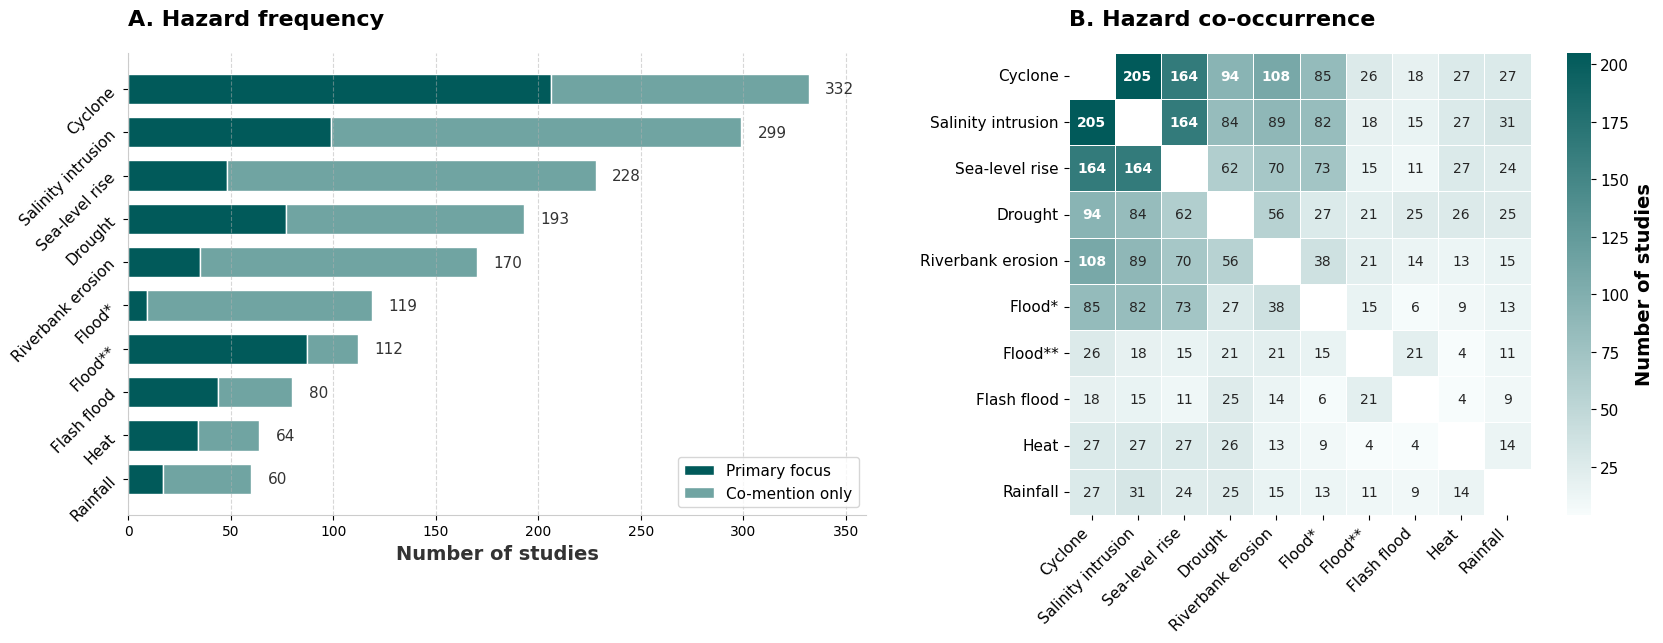

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 1. Prepare Left Panel Data (Hazard Frequency)
hazards = [
    "Cyclone", "Salinity intrusion", "Sea-level rise", "Drought",
    "Riverbank erosion", "Flood*", "Flood**", "Flash flood", "Heat", "Rainfall"
]

# Reverse arrays so the highest frequency appears at the top of the horizontal bar chart
hazards = hazards[::-1]
primary = [206, 99, 48, 77, 35, 9, 87, 44, 34, 17][::-1]
comention = [126, 200, 180, 116, 135, 110, 25, 36, 30, 43][::-1]
total = [332, 299, 228, 193, 170, 119, 112, 80, 64, 60][::-1]

# 2. Prepare Right Panel Data (Heatmap)
# Diagonals are set to np.nan to appear blank, matching your request
heatmap_data = [
    [np.nan, 205, 164, 94, 108, 85, 26, 18, 27, 27],
    [205, np.nan, 164, 84, 89, 82, 18, 15, 27, 31],
    [164, 164, np.nan, 62, 70, 73, 15, 11, 27, 24],
    [94, 84, 62, np.nan, 56, 27, 21, 25, 26, 25],
    [108, 89, 70, 56, np.nan, 38, 21, 14, 13, 15],
    [85, 82, 73, 27, 38, np.nan, 15, 6, 9, 13],
    [26, 18, 15, 21, 21, 15, np.nan, 21, 4, 11],
    [18, 15, 11, 25, 14, 6, 21, np.nan, 4, 9],
    [27, 27, 27, 26, 13, 9, 4, 4, np.nan, 14],
    [27, 31, 24, 25, 15, 13, 11, 9, 14, np.nan]
]

hazards_heat = [
    "Cyclone", "Salinity intrusion", "Sea-level rise", "Drought",
    "Riverbank erosion", "Flood*", "Flood**", "Flash flood", "Heat", "Rainfall"
]
df_heat = pd.DataFrame(heatmap_data, index=hazards_heat, columns=hazards_heat)

# 3. Figure Setup
# Set exact dimensions for a wide, two-panel layout perfect for manuscript submission
fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=.1)

# Define the precise color palette from the reference image
color_primary = "#015a5a"  # Dark teal
color_comention = "#70a4a2" # Light teal
cmap_heat = LinearSegmentedColormap.from_list("custom_teal", ["#f7fcfc", color_primary])

# --- Panel A: Hazard Frequency ---
ax1 = axes[0]
y_pos = np.arange(len(hazards))

# Plot stacked bars
ax1.barh(y_pos, primary, color=color_primary, edgecolor='white', height=0.7, label='Primary focus')
ax1.barh(y_pos, comention, left=primary, color=color_comention, edgecolor='white', height=0.7, label='Co-mention only')

# Annotate total counts at the end of each bar
for i, (p, c, t) in enumerate(zip(primary, comention, total)):
    ax1.text(t + 8, i, str(t), va='center', fontsize=11, color='#333333')

# Format Left Panel axes
ax1.set_yticks(y_pos)
ax1.set_yticklabels(hazards, fontsize=11, rotation=45)
ax1.set_xlabel('Number of studies', fontsize=14, fontweight='bold', color='#333333')
ax1.set_title('A. Hazard frequency', loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='lower right', fontsize=11, frameon=True)

# Grid and spine styling
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.set_xlim(0, 360)

# --- Panel B: Hazard Co-occurrence ---
ax2 = axes[1]
sns.heatmap(df_heat, ax=ax2, cmap=cmap_heat, annot=True, fmt='g',
            cbar_kws={'label': 'Number of studies'}, linewidths=.5,
            linecolor='white', square=True)

# Target the top 5 values for bolding (94, 108, 164, 164, 205)
top_5_threshold = 94

for text in ax2.texts:
    if text.get_text() != 'nan':
        val = float(text.get_text())
        if val >= top_5_threshold:
            text.set_weight('bold')
            text.set_color('white')
    else:
        text.set_text('') # Clear the 'nan' text from the diagonal

# Format Right Panel axes
ax2.set_title('B. Hazard co-occurrence', loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=11)

# Format the colorbar
cbar = ax2.collections[0].colorbar
cbar.ax.yaxis.label.set_size(14)
cbar.ax.yaxis.label.set_weight('bold')
cbar.ax.tick_params(labelsize=11)

# Render the high-resolution plot
plt.savefig("hazard_figure.png", dpi=300, bbox_inches='tight')
plt.savefig("hazard_figure.pdf", dpi =300, bbox_inches='tight')

plt.show()